<a href="https://colab.research.google.com/github/ydv-prince/EDA/blob/main/EDA_2_Car_Sale_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
url = 'https://drive.google.com/uc?id=1N0kM_zi-iU3yvr6BEJf21aiF599PtA0U'

In [4]:
df = pd.read_csv(url)

In [5]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [7]:
# Car_id: A unique identifier for each car in the dataset, helping to track individual car entries.
# Date: The date when the car sale transaction took place, formatted as YYYY-MM-DD.
# Customer Name: The name of the customer who purchased the car, represented as a string.
# Gender: The gender of the customer, categorized as "Male" or "Female.
# Annual Income: The customer's annual income in US dollars, represented as a numeric value.
# Dealer_Name: The name of the dealership selling the car, represented as a string.
# Company: The manufacturer or brand name of the car, such as "Toyota," "Ford," etc.
# Model: The specific model name of the car, such as "Corolla," "Civic," etc.
# Engine: The engine type of the car, such as "V6," "I4," etc.
# Transmission: The type of transmission in the car, either "Manual" or "Automatic.
# Color: The color of the car, represented as a string (e.g., "Red," "Blue").
# Price ($): The selling price of the car in US dollars.
# Dealer_No: A unique identifier for each car dealer in the dataset.
# Body Style: The body style of the car, such as "Sedan," "SUV," etc.
# Phone: The phone number of the customer who purchased the car.
# Dealer_Region: The geographical region of the car dealer, such as "North," "South," etc.

In [8]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [9]:
df['Price'] = df['Price ($)']

In [10]:
df.drop('Price ($)', axis = 1, inplace = True)

In [11]:
df['Dealer_No'] = df['Dealer_No ']
df.drop('Dealer_No ', axis = 1, inplace = True)

In [12]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Body Style', 'Phone', 'Dealer_Region', 'Price', 'Dealer_No'],
      dtype='object')

In [13]:
#Q1. What is the average selling price of cars for each dealer, and how does it compare across different dealers?

avg_selling_price = df.groupby('Dealer_No')['Price'].mean().reset_index()
avg_selling_price

,Dealer_No,Price
0,06457-3834,27771.614943
1,38701-8047,28208.618455
2,53546-9427,28009.712038
3,60504-7114,28134.025879
4,78758-7841,28272.412204
5,85257-3102,28259.141059
6,99301-3882,27920.853768


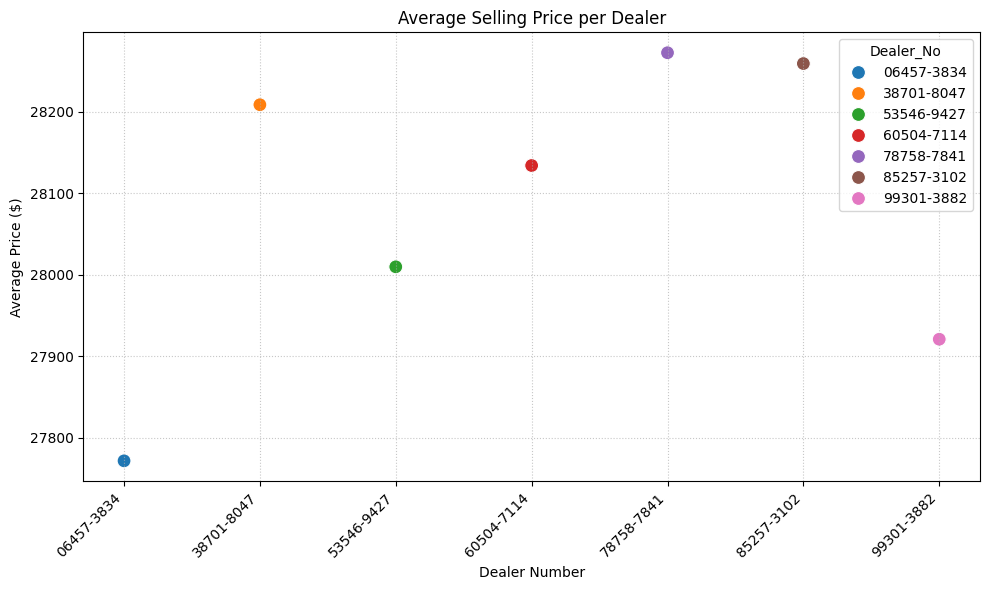

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=avg_selling_price, x='Dealer_No', y='Price', hue='Dealer_No', s=100, legend='full')
plt.title('Average Selling Price per Dealer')
plt.xlabel('Dealer Number')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
#Q2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

company_price_std = df.groupby('Company')['Price'].std().reset_index()
company_price_std

,Company,Price
0,Acura,8183.046414
1,Audi,12904.243867
2,BMW,15065.578723
3,Buick,17142.232626
4,Cadillac,19517.120220
5,Chevrolet,13311.063223
6,Chrysler,11583.286811
7,Dodge,11187.592085
8,Ford,15849.090227
9,Honda,11148.629062


In [16]:
company_with_highest_std = company_price_std.loc[company_price_std['Price'].idxmax()]
company_with_highest_std

,15
Company,Lincoln
Price,19658.050211


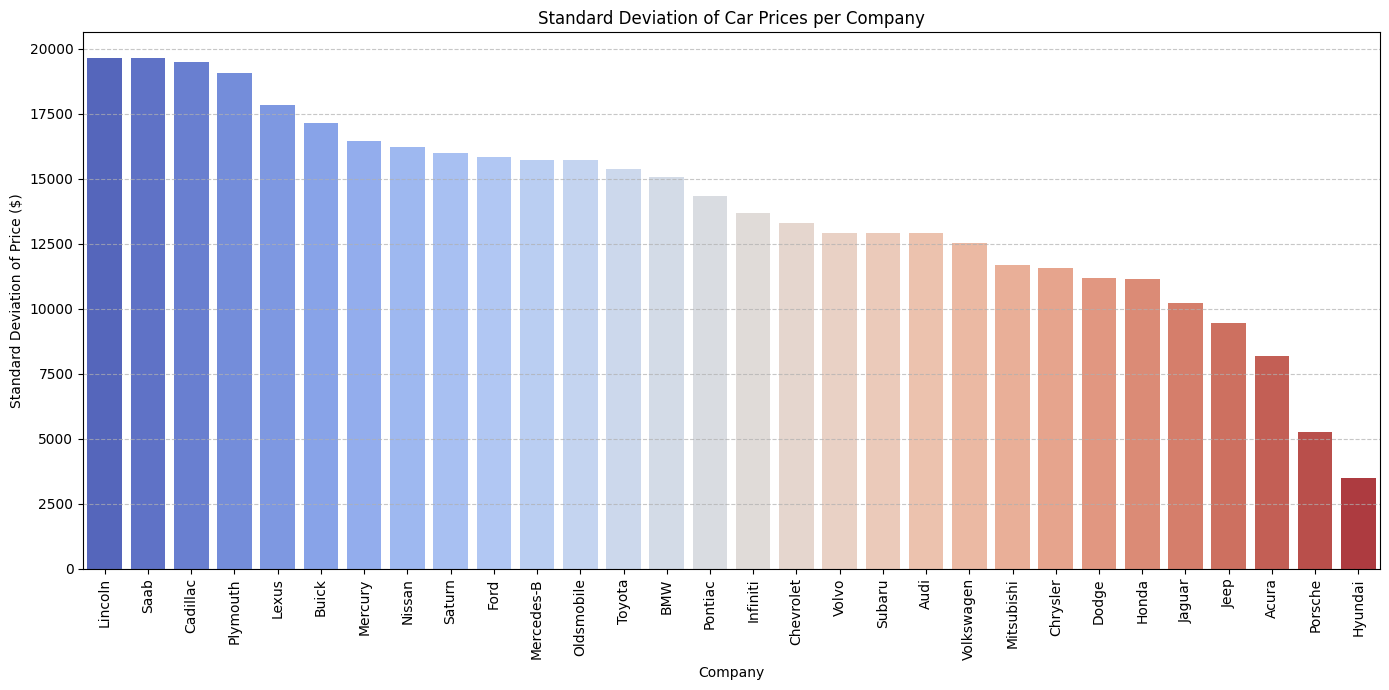

In [17]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Company', y='Price', data=company_price_std.sort_values(by='Price', ascending=False), palette='coolwarm')
plt.title('Standard Deviation of Car Prices per Company')
plt.xlabel('Company')
plt.ylabel('Standard Deviation of Price ($)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

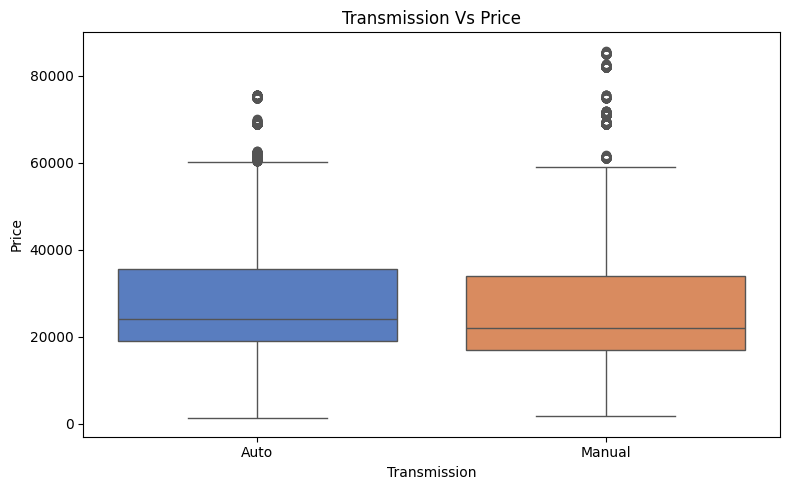

In [18]:
#Q3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

plt.figure(figsize=(8, 5))
sns.boxplot(x = 'Transmission', y = 'Price', data = df, palette = 'muted')
plt.title('Transmission Vs Price')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Price')

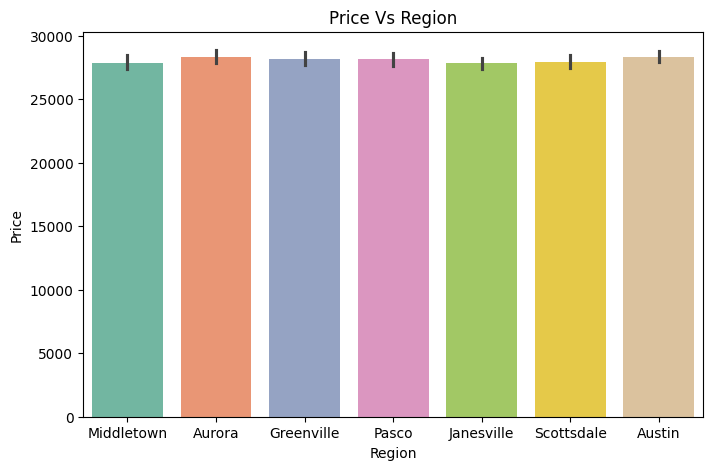

In [19]:
#Q4. What is the distribution of car prices across different regions?

plt.figure(figsize = (8,5))
sns.barplot(x = 'Dealer_Region', y = 'Price', data = df, palette = 'Set2')
plt.title('Price Vs Region')
plt.xlabel('Region')
plt.ylabel('Price')

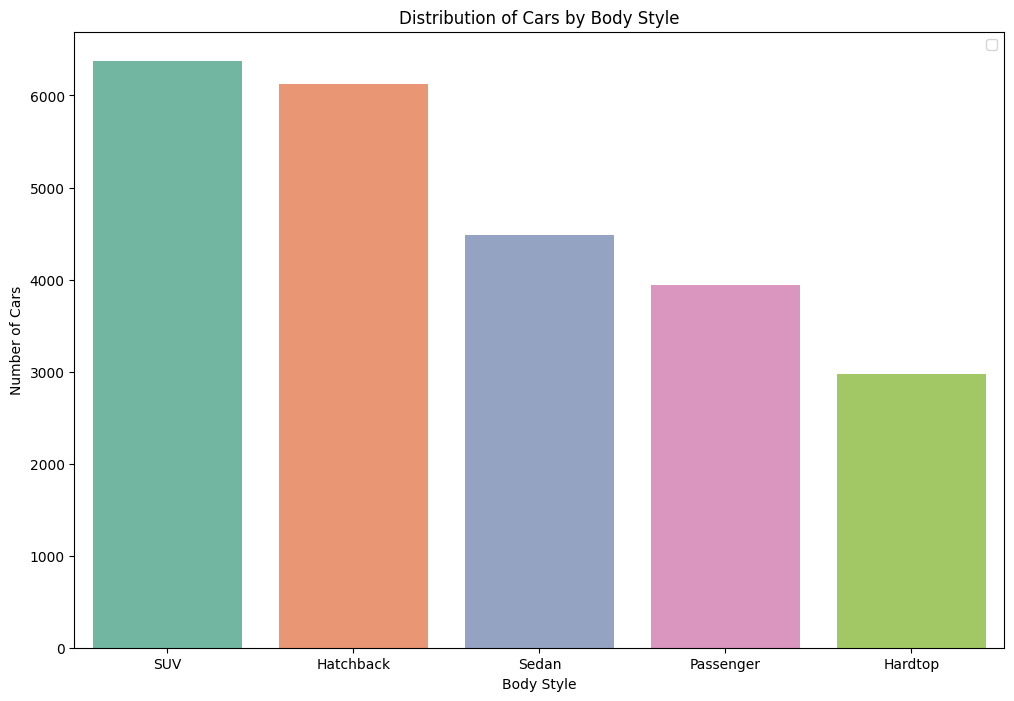

In [20]:
#Q5. What is the distribution of cars based on body styles?

plt.figure(figsize=(12,8))
sns.countplot(x = 'Body Style', data=df, order=df['Body Style'].value_counts().index, palette='Set2')
plt.xlabel('Body Style')
plt.ylabel('Number of Cars')
plt.title('Distribution of Cars by Body Style')
plt.legend()
plt.show()

<Axes: xlabel='Price', ylabel='Annual Income'>

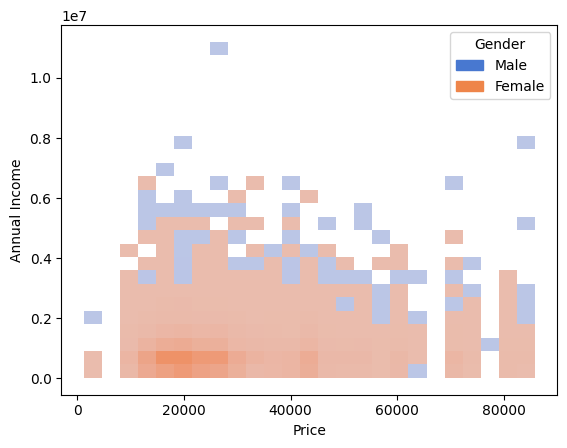

In [21]:
#6. How does the average selling price of cars vary by customer gender and annual income?

sns.histplot(x = 'Price', y = 'Annual Income', bins = 25, data = df, hue = 'Gender', palette = 'muted')

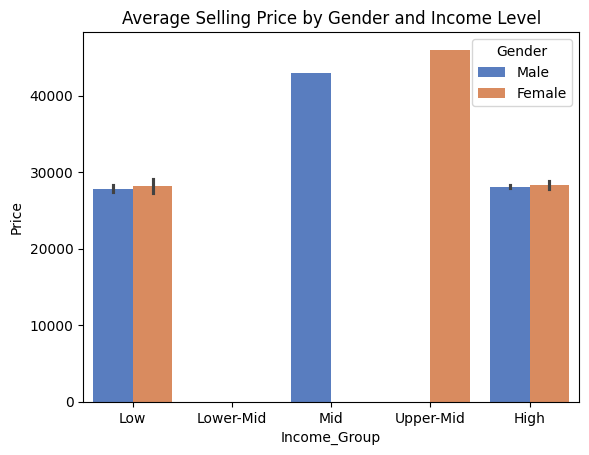

In [22]:
df['Income_Group'] = pd.cut(
    df['Annual Income'],
    bins=[0, 30000, 60000, 90000, 120000, df['Annual Income'].max()],
    labels=['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High']
)

sns.barplot(
    x='Income_Group',
    y='Price',
    hue='Gender',
    data=df,
    palette='muted'
)

plt.title('Average Selling Price by Gender and Income Level')
plt.show()


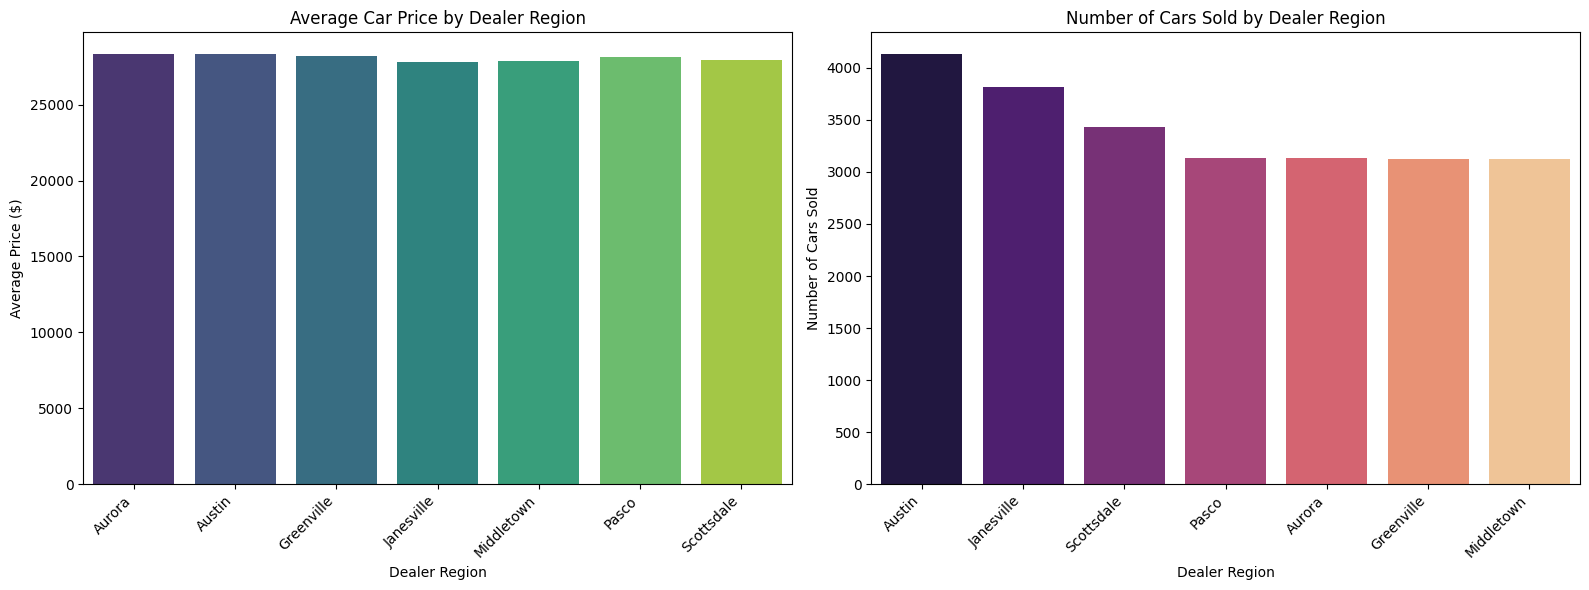

In [23]:
#Q7. What is the distribution of car prices by region, and how does the number of cars sold vary by region?

avg_price_by_region = df.groupby('Dealer_Region')['Price'].mean().reset_index()

# Calculate number of cars sold by region
cars_sold_by_region = df['Dealer_Region'].value_counts().reset_index()
cars_sold_by_region.columns = ['Dealer_Region', 'Number of Cars Sold']

plt.figure(figsize = (16, 6))

# Subplot 1: Distribution of car prices by region
plt.subplot(1, 2, 1)
sns.barplot(x = 'Dealer_Region', y = 'Price', data = avg_price_by_region, palette = 'viridis')
plt.title('Average Car Price by Dealer Region')
plt.xlabel('Dealer Region')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')

# Subplot 2: Number of cars sold by region
plt.subplot(1, 2, 2)
sns.barplot(x = 'Dealer_Region', y = 'Number of Cars Sold', data = cars_sold_by_region, palette = 'magma')
plt.title('Number of Cars Sold by Dealer Region')
plt.xlabel('Dealer Region')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

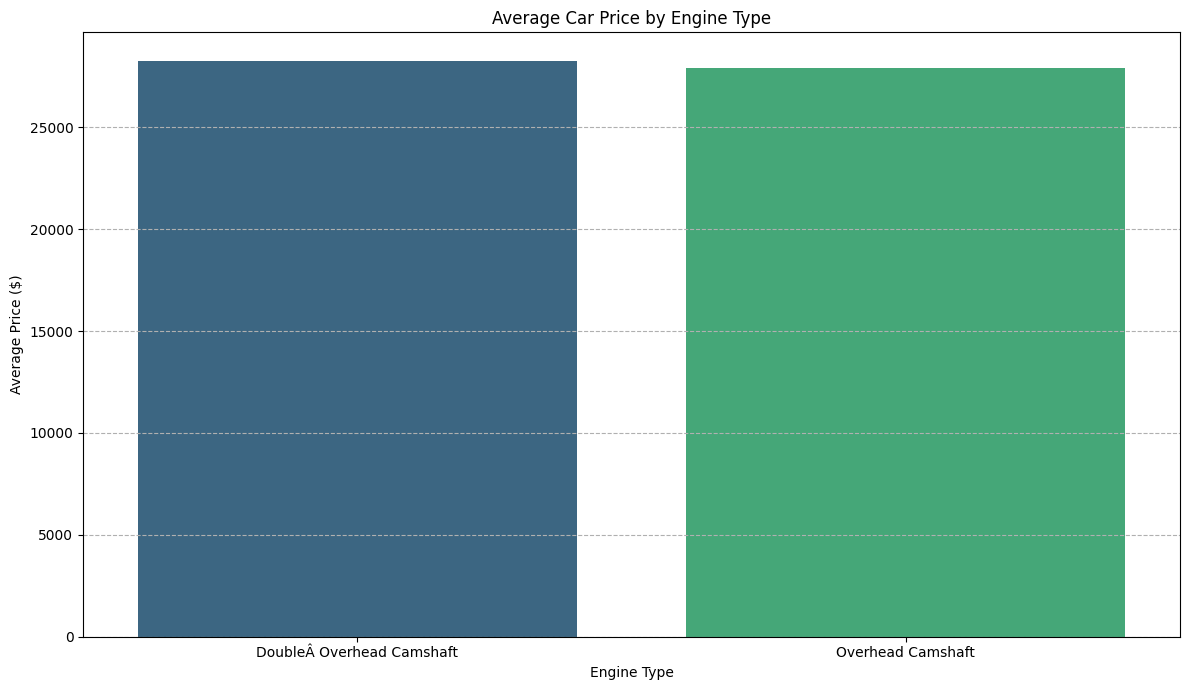

In [24]:
#Q8. How does the average car price differ between cars with different engine sizes?

avg_price_by_engine = df.groupby('Engine')['Price'].mean().reset_index()

avg_price_by_engine = avg_price_by_engine.sort_values(by='Price', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Engine', y='Price', data=avg_price_by_engine, palette='viridis')
plt.title('Average Car Price by Engine Type')
plt.xlabel('Engine Type')
plt.ylabel('Average Price ($)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

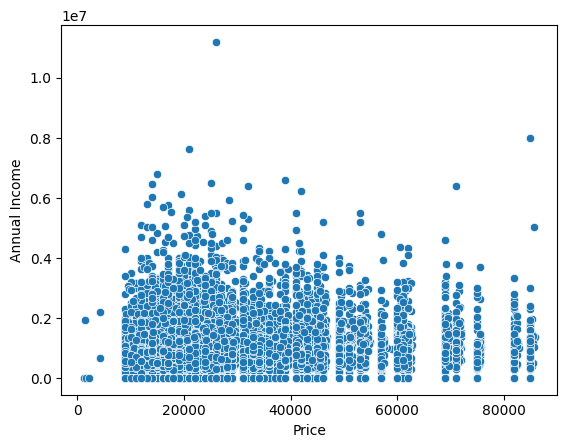

In [25]:
#Q9. How do car prices vary based on the customer’s annual income bracket?

sns.scatterplot(x = 'Price', y = 'Annual Income', data = df, palette = 'magma')
plt.show()

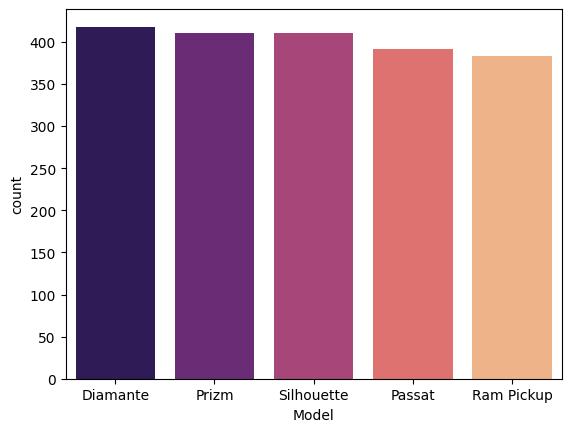

In [40]:
#Q10. What are the top 5 car models with the highest number of sales, and how does their price distribution look?

top_5_models = df['Model'].value_counts().head(5).reset_index()
sns.barplot(x = 'Model', y = 'count', data = top_5_models, palette = 'magma')
plt.show()

In [41]:
from scipy.stats import f_oneway

anova_data = [
    top_models_df[top_models_df['Model'] == model]['Price']
    for model in top_5_models.index
]

f_stat, p_value = f_oneway(*anova_data)

f_stat, p_value


(np.float64(nan), np.float64(nan))

In [42]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Body Style', 'Phone', 'Dealer_Region', 'Price', 'Dealer_No',
       'Income_Group'],
      dtype='object')

In [56]:
df.Engine.unique()

array(['DoubleÂ\xa0Overhead Camshaft', 'Overhead Camshaft'], dtype=object)

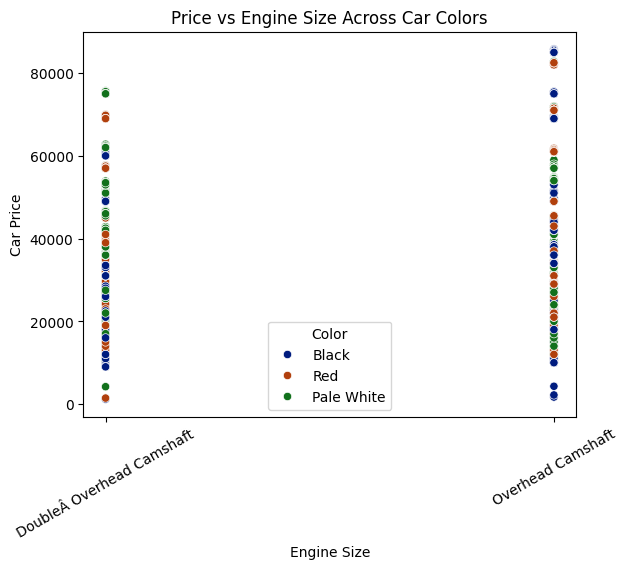

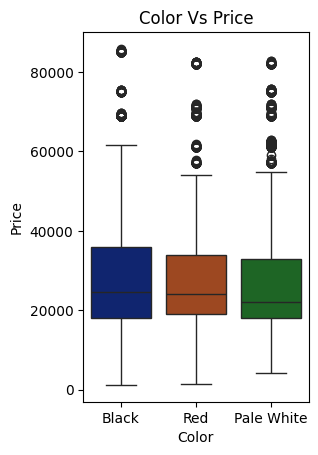

In [69]:
#Q11. How does car price vary with engine size across different car colors, and which colors have the highest price variation?

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.scatterplot(x = 'Engine', y = 'Price', data = df, hue = 'Color', palette = 'dark')
plt.xlabel('Engine Size')
plt.ylabel('Car Price')
plt.xticks(rotation = 30)
plt.title('Price vs Engine Size Across Car Colors')
plt.show()

plt.subplot(1,2,2)
sns.boxplot(x = 'Color', y = 'Price', data = df, palette = 'dark')
plt.title('Color Vs Price')
plt.xlabel('Color')
plt.ylabel('Price')
plt.show()

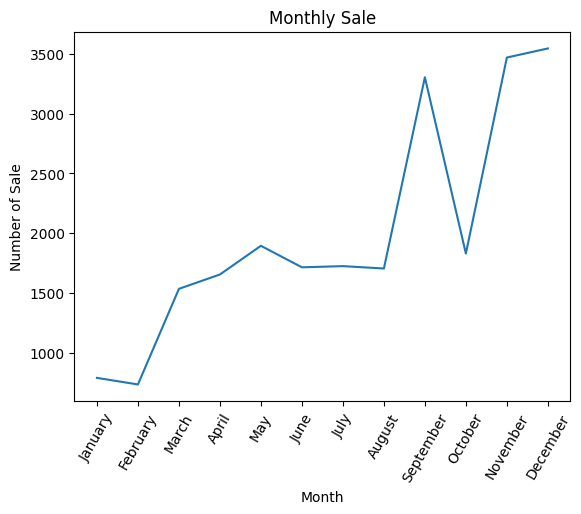

In [85]:
#Q12. Is there any seasonal trend in car sales based on the date of sale?

df['Date'] = pd.to_datetime(df['Date'])
df['Month_Name'] = df['Date'].dt.month_name()
monthly_sales = df.groupby('Month_Name')['Car_id'].count().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']).reset_index()

plt.figure()
sns.lineplot(x = 'Month_Name', y = 'Car_id', data = monthly_sales, palette = 'coolwarm')
plt.title('Monthly Sale')
plt.xlabel('Month')
plt.xticks(rotation = 60)
plt.ylabel('Number of Sale')
plt.show()

In [86]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Body Style', 'Phone', 'Dealer_Region', 'Price', 'Dealer_No',
       'Income_Group', 'Data', 'Monthly_Name', 'Month_Name'],
      dtype='object')

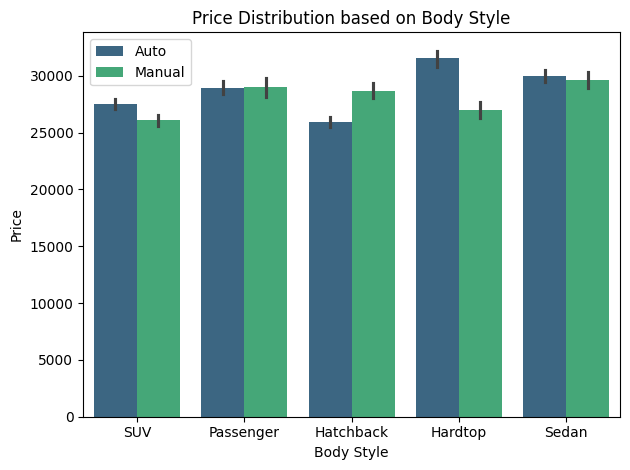

In [91]:
#Q13. How does the car price distribution change when considering different combinations of body style and transmission type?

sns.barplot(x = 'Body Style', y = 'Price', hue = 'Transmission', data = df, palette = 'viridis')
plt.title('Price Distribution based on Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

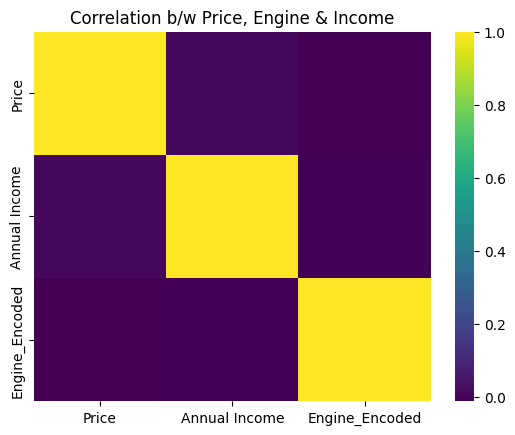

In [119]:
#Q14. What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Engine_Encoded'] = encoder.fit_transform(df[['Engine']])

corr = df[['Price', 'Annual Income', 'Engine_Encoded']].corr()

sns.heatmap(corr, cmap = 'viridis', fmt = '.2f')
plt.title('Correlation b/w Price, Engine & Income')
plt.show()

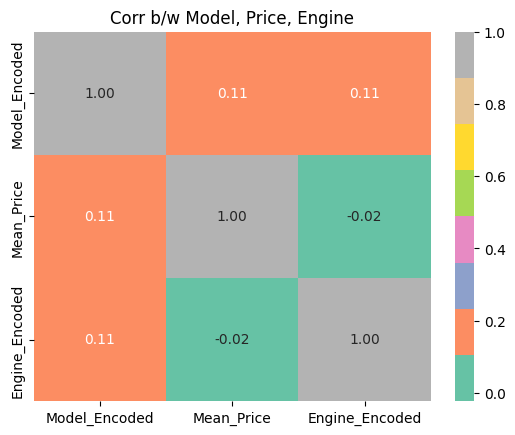

In [148]:
#Q15. How does the average car price vary across different car models and engine types?

df['Model_Encoded'] = encoder.fit_transform(df[['Model']])
df['Mean_Price'] = df.groupby('Model')['Price'].transform('mean')

corr = df[['Model_Encoded', 'Mean_Price', 'Engine_Encoded']].corr()
plt.title('Corr b/w Model, Price, Engine')
sns.heatmap(corr, annot = True, cmap = 'Set2', fmt = '.2f')
plt.show()